# Phân tích Khám phá Dữ liệu (EDA) & Khai phá Insight - Dự án Zomato 

**Mục tiêu của Notebook này:**
Notebook này nhằm mục đích "thấu hiểu" bộ dữ liệu Zomato sau khi đã làm sạch. Chúng ta sẽ đi từ việc nắm bắt các đặc điểm cơ bản của từng biến số (Phần 1), đến việc tìm ra mối quan hệ ẩn giấu giữa các biến (Phần 2), và cuối cùng là sử dụng các kiểm định thống kê để chứng minh các giả thuyết một cách khoa học (Phần 3).

---
## Khởi tạo Môi trường & Nạp Dữ liệu

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd           
import numpy as np             
import matplotlib.pyplot as plt 
import seaborn as sns          
import scipy.stats as stats    
import warnings
from src.data.load_data import load_raw_data
from src.data.clean_data import clean_basic
from src.features.build_features import get_da_data,get_ds_data                 

In [3]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
%matplotlib inline

In [4]:
df = load_raw_data()
df.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df_clean = get_da_data(df)
df_clean.head(5)


--- DA Feature Engineering 
 Cleaning data
Clean hoàn tất, kích thước dữ liệu hiện tại: (9551, 21)
Hoàn tất xử lí dữ liệu DA. Kích thước: (9551, 18)


,Restaurant Name,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,Izakaya Kikufuji,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,4.4,Green,Very Good,270,Phillipines
3,Ooma,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,Sambo Kojin,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


---
## Phần 1: Thống kê mô tả tổng quan (Univariate Analysis)
**Mục tiêu:** Hiểu rõ hình hài, sự phân bố và các đặc trưng thống kê cơ bản của từng biến độc lập trong bộ dữ liệu Zomato.

### 1.1 Phân bố của Điểm đánh giá (Aggregate Rating) & Lượt bình chọn (Votes)
**Câu hỏi phân tích:**
- Phần lớn các nhà hàng trên Zomato nhận được mức điểm đánh giá nào? Dữ liệu có bị lệch (skewed) về một phía không?
- Tỷ lệ nhà hàng chưa được đánh giá (Rating = 0.0) chiếm bao nhiêu phần trăm?
- Lượng Votes phân bố ra sao? Liệu có phải chỉ một số ít nhà hàng chiếm đại đa số lượt bình chọn?


--- THỐNG KÊ ĐIỂM ĐÁNH GIÁ (ĐÃ ĐIỀU CHỈNH) ---
Tổng số nhà hàng: 9551
Số nhà hàng CHƯA được đánh giá (Rating = 0.0): 2148 (Chiếm 22.49%)
Số nhà hàng ĐÃ được đánh giá: 7403

-> Điểm trung bình thực tế (Mean): 3.44
-> Điểm trung vị thực tế (Median): 3.40


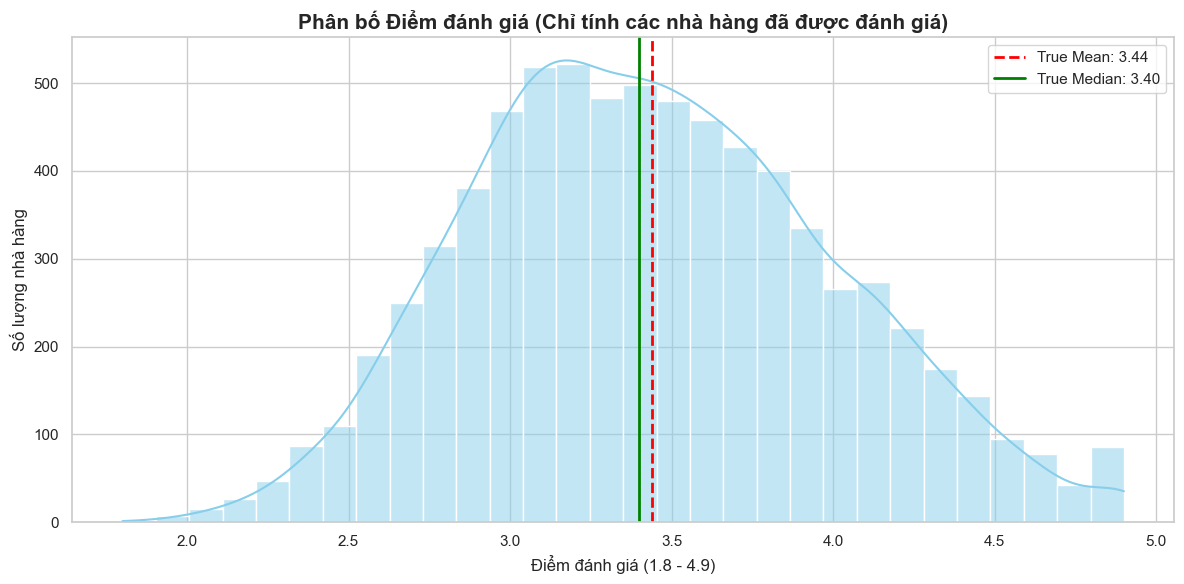

In [6]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# 1. TÁCH DỮ LIỆU ĐỂ TÍNH TOÁN CHÍNH XÁC
df_rated = df_clean[df_clean['Aggregate rating'] > 0]
unrated_count = len(df_clean[df_clean['Aggregate rating'] == 0.0])
total_restaurants = len(df_clean)

print(f"--- THỐNG KÊ ĐIỂM ĐÁNH GIÁ (ĐÃ ĐIỀU CHỈNH) ---")
print(f"Tổng số nhà hàng: {total_restaurants}")
print(f"Số nhà hàng CHƯA được đánh giá (Rating = 0.0): {unrated_count} (Chiếm {(unrated_count/total_restaurants)*100:.2f}%)")
print(f"Số nhà hàng ĐÃ được đánh giá: {len(df_rated)}\n")

# Tính Mean và Median thực sự (Chỉ trên tập đã đánh giá)
true_mean = df_rated['Aggregate rating'].mean()
true_median = df_rated['Aggregate rating'].median()

print(f"-> Điểm trung bình thực tế (Mean): {true_mean:.2f}")
print(f"-> Điểm trung vị thực tế (Median): {true_median:.2f}")

# 2. VẼ BIỂU ĐỒ TRÊN TẬP ĐÃ ĐÁNH GIÁ
plt.figure(figsize=(12, 6))
sns.histplot(data=df_rated, x='Aggregate rating', bins=30, kde=True, color='skyblue')

# Thêm đường trung bình và trung vị thực sự
plt.axvline(true_mean, color='red', linestyle='--', linewidth=2, label=f'True Mean: {true_mean:.2f}')
plt.axvline(true_median, color='green', linestyle='-', linewidth=2, label=f'True Median: {true_median:.2f}')

plt.title('Phân bố Điểm đánh giá (Chỉ tính các nhà hàng đã được đánh giá)', fontsize=15, fontweight='bold')
plt.xlabel('Điểm đánh giá (1.8 - 4.9)', fontsize=12)
plt.ylabel('Số lượng nhà hàng', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

--- THỐNG KÊ LƯỢT BÌNH CHỌN (VOTES) ---
95% nhà hàng trên Zomato có số lượt bình chọn dưới ngưỡng: 699 lượt.
Chỉ riêng Top 5% nhà hàng hot nhất đã chiếm tới 49.10% tổng số lượt bình chọn trên toàn hệ thống!



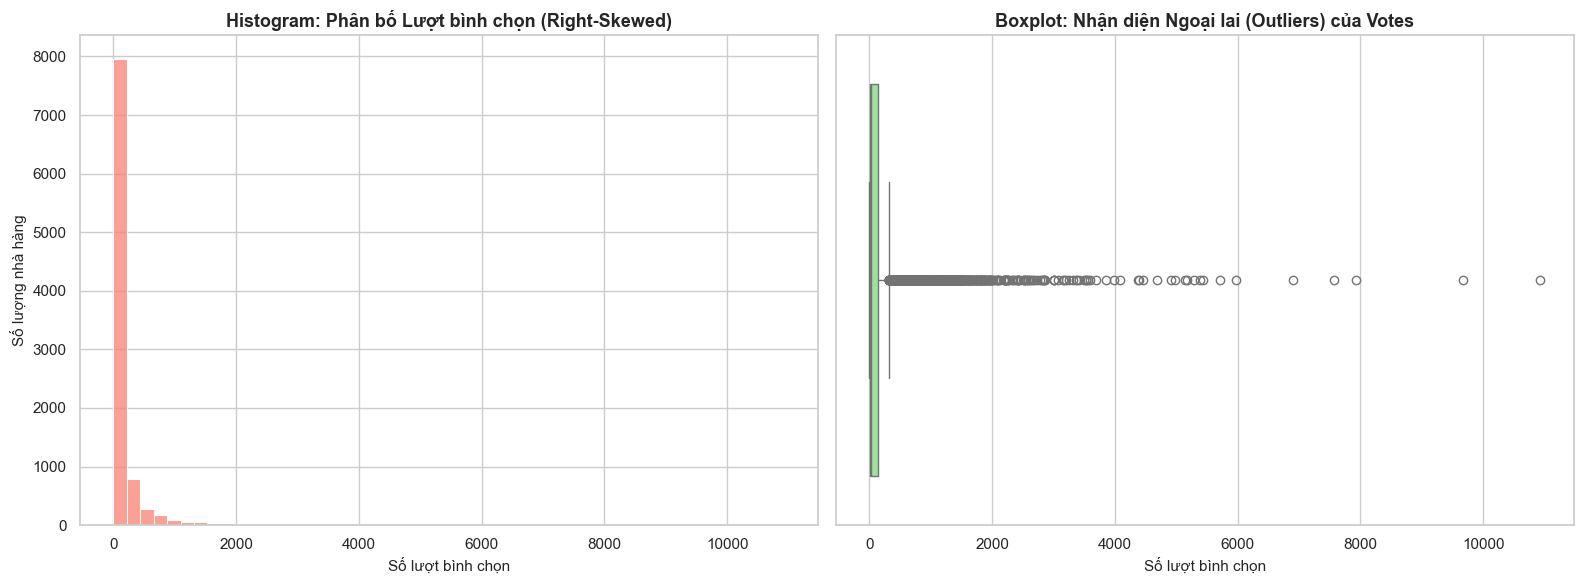

In [7]:
# 1. TÍNH TOÁN THỐNG KÊ CHO VOTES
total_votes = df_clean['Votes'].sum()
# Tìm ngưỡng Votes của Top 5% nhà hàng nhiều votes nhất
top_5_percentile_threshold = df_clean['Votes'].quantile(0.95)

# Tính tổng số votes của nhóm Top 5% này
votes_of_top_5_pct = df_clean[df_clean['Votes'] >= top_5_percentile_threshold]['Votes'].sum()
concentration_pct = (votes_of_top_5_pct / total_votes) * 100

print(f"--- THỐNG KÊ LƯỢT BÌNH CHỌN (VOTES) ---")
print(f"95% nhà hàng trên Zomato có số lượt bình chọn dưới ngưỡng: {top_5_percentile_threshold:.0f} lượt.")
print(f"Chỉ riêng Top 5% nhà hàng hot nhất đã chiếm tới {concentration_pct:.2f}% tổng số lượt bình chọn trên toàn hệ thống!\n")

# 2. VẼ BIỂU ĐỒ PHÂN BỐ VOTES (Sử dụng 2 đồ thị song song)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Histogram (KDE)
sns.histplot(data=df_clean, x='Votes', bins=50, color='salmon', ax=axes[0])
axes[0].set_title('Histogram: Phân bố Lượt bình chọn (Right-Skewed)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượt bình chọn', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Đồ thị 2: Boxplot (Nhận diện Outliers)
sns.boxplot(data=df_clean, x='Votes', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot: Nhận diện Ngoại lai (Outliers) của Votes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượt bình chọn', fontsize=11)

plt.tight_layout()
plt.show()

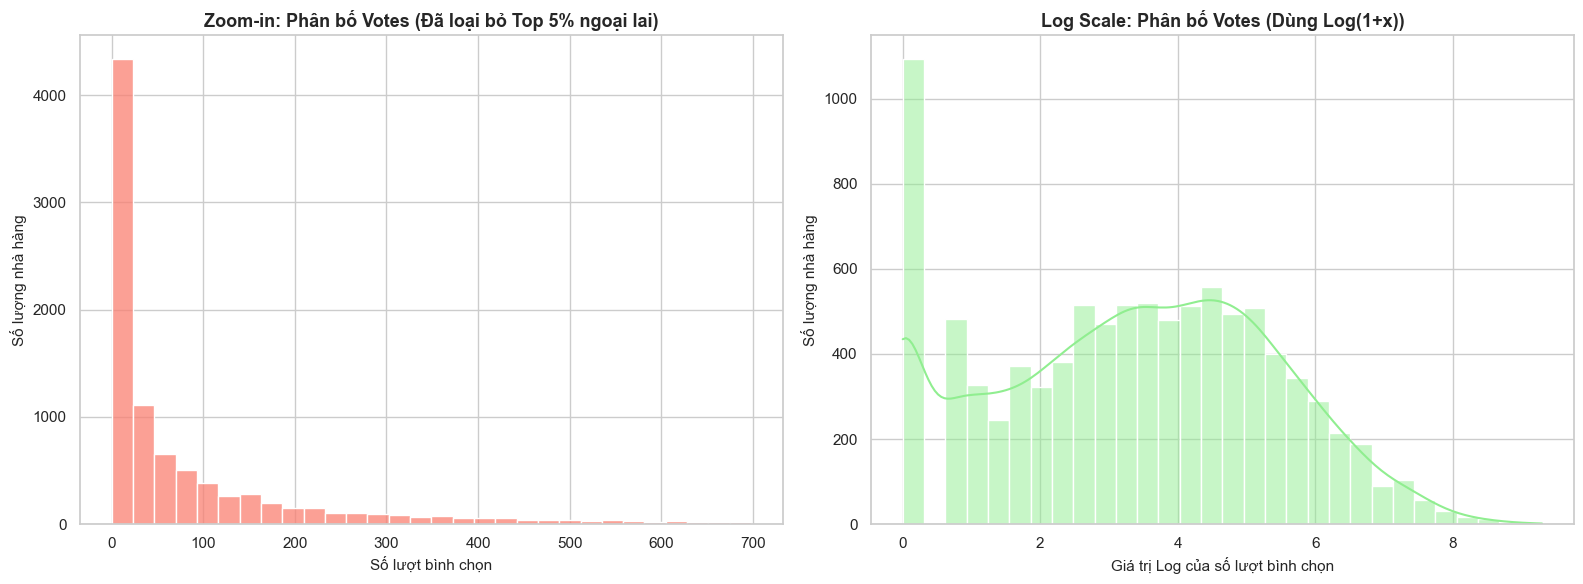

In [8]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: ZOOM IN (Chỉ lấy 95% nhà hàng bình thường)
# Dùng top_5_percentile_threshold đã tính ở ô trước
sns.histplot(data=df_clean[df_clean['Votes'] < top_5_percentile_threshold], 
             x='Votes', bins=30, color='salmon', ax=axes[0])
axes[0].set_title('Zoom-in: Phân bố Votes (Đã loại bỏ Top 5% ngoại lai)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượt bình chọn', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Đồ thị 2: LOG TRANSFORMATION (Nhìn toàn cảnh bằng lăng kính Logarit)
# Tạo một cột tạm thời chuyển đổi Votes sang Log1p
log_votes = np.log1p(df_clean['Votes'])
sns.histplot(x=log_votes, bins=30, color='lightgreen', kde=True, ax=axes[1])
axes[1].set_title('Log Scale: Phân bố Votes (Dùng Log(1+x))', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá trị Log của số lượt bình chọn', fontsize=11)
axes[1].set_ylabel('Số lượng nhà hàng', fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Điểm đánh giá (Rating): Dữ liệu bị phân hóa thành 2 nhóm rõ rệt. Một lượng rất lớn nhà hàng chiếm hơn 20% (bạn xem số liệu in ra cụ thể để điền vào) hoàn toàn chưa có lượt đánh giá nào (Rating = 0.0). Đối với các nhà hàng đã được đánh giá, điểm số phân bố theo dạng xấp xỉ phân phối chuẩn (Normal Distribution), lệch nhẹ về bên trái (Left-skewed) với đỉnh tập trung ở dải điểm từ 3.0 đến 4.0.

2. Về Lượt bình chọn (Votes): Dữ liệu phân bố cực kỳ lệch phải (Right-skewed). Đa số các nhà hàng có rất ít lượt bình chọn (tập trung ở mức gần 0). Biểu đồ Boxplot cho thấy vô số các điểm ngoại lai (outliers) kéo dài về phía bên phải.

3. Tính tập trung: Số liệu chứng minh quy luật Pareto (Quy luật 80/20) tồn tại mạnh mẽ: Chỉ một nhóm cực nhỏ (Top 5% nhà hàng) đã thâu tóm phần lớn lượng tương tác của toàn bộ nền tảng Zomato.

### 1.2 Phân tích Chi phí trung bình (Average Cost for two) & Phân khúc giá (Price range)
**Câu hỏi phân tích:**
- Mức giá trung bình cho 2 người ăn thường rơi vào khoảng nào? Có xuất hiện các giá trị ngoại lệ (outliers - nhà hàng quá xa xỉ) không?
- Tỷ trọng các nhà hàng thuộc các phân khúc giá (Price range 1 đến 4) phân bổ như thế nào? Zomato chủ yếu phục vụ khách hàng bình dân hay cao cấp?


--- THỐNG KÊ CHI PHÍ CHO 2 NGƯỜI (RAW DATA) ---
Mức giá trung vị (Median): 400
95% các nhà hàng có mức giá thấp hơn hoặc bằng: 1700



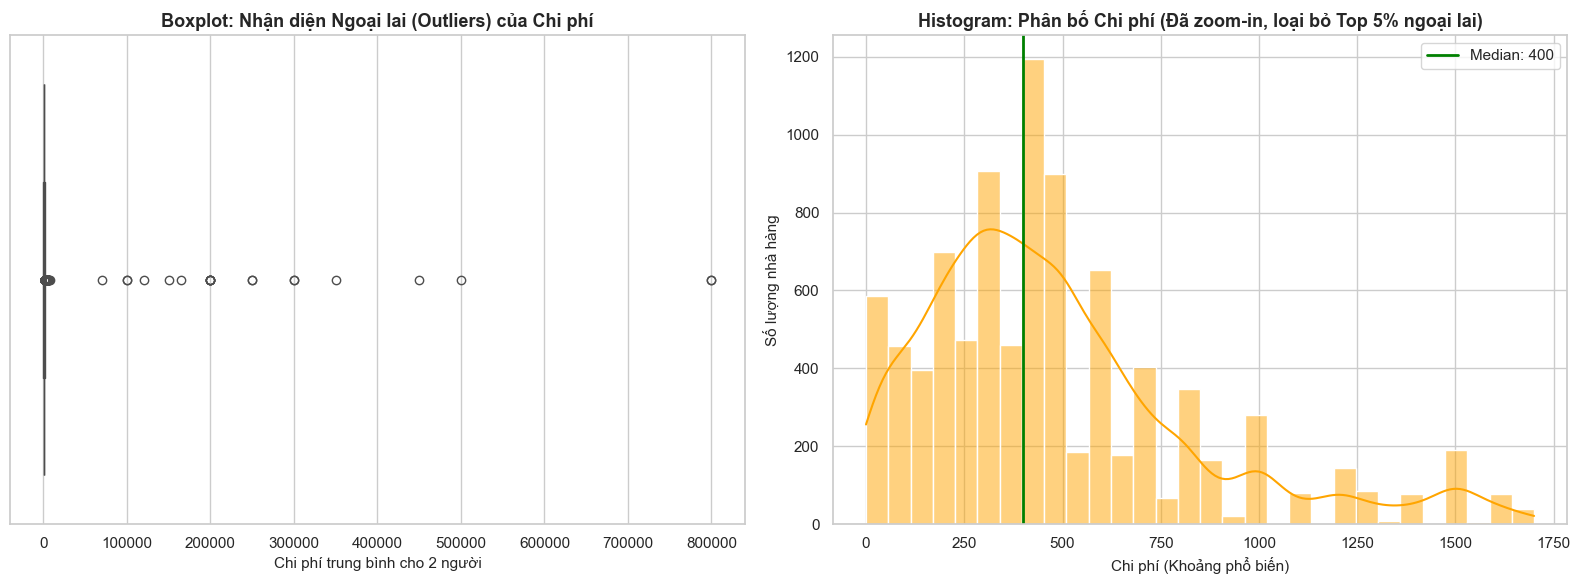

In [9]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# 1. TÍNH TOÁN THỐNG KÊ CHI PHÍ TRUNG BÌNH
# Tính phân vị thứ 95 để tìm ra ngưỡng loại bỏ các outliers cực đoan (thường do khác tiền tệ)
cost_95th_percentile = df_clean['Average Cost for two'].quantile(0.95)
median_cost = df_clean['Average Cost for two'].median()

print(f"--- THỐNG KÊ CHI PHÍ CHO 2 NGƯỜI (RAW DATA) ---")
print(f"Mức giá trung vị (Median): {median_cost:.0f}")
print(f"95% các nhà hàng có mức giá thấp hơn hoặc bằng: {cost_95th_percentile:.0f}\n")

# 2. VẼ BIỂU ĐỒ PHÂN BỐ CHI PHÍ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Boxplot nhìn toàn cảnh Outliers
sns.boxplot(data=df_clean, x='Average Cost for two', color='gold', ax=axes[0])
axes[0].set_title('Boxplot: Nhận diện Ngoại lai (Outliers) của Chi phí', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Chi phí trung bình cho 2 người', fontsize=11)

# Đồ thị 2: Histogram Zoom-in (Chỉ lấy 95% dữ liệu phổ biến)
df_zoomed_cost = df_clean[df_clean['Average Cost for two'] <= cost_95th_percentile]
sns.histplot(data=df_zoomed_cost, x='Average Cost for two', bins=30, kde=True, color='orange', ax=axes[1])
axes[1].axvline(median_cost, color='green', linestyle='-', linewidth=2, label=f'Median: {median_cost:.0f}')

axes[1].set_title('Histogram: Phân bố Chi phí (Đã zoom-in, loại bỏ Top 5% ngoại lai)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Chi phí (Khoảng phổ biến)', fontsize=11)
axes[1].set_ylabel('Số lượng nhà hàng', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

--- THỐNG KÊ PHÂN KHÚC GIÁ ---
Phân khúc 1: 4444 nhà hàng (46.53%)
Phân khúc 2: 3113 nhà hàng (32.59%)
Phân khúc 3: 1408 nhà hàng (14.74%)
Phân khúc 4: 586 nhà hàng (6.14%)



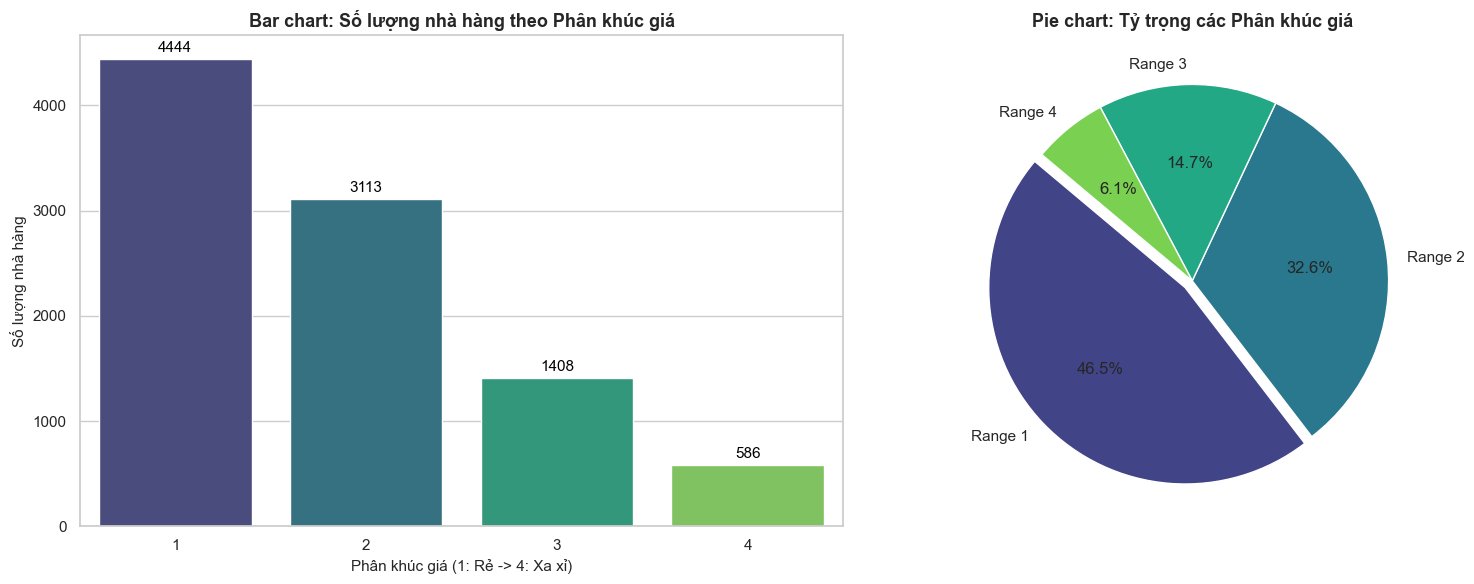

In [10]:
# 1. TÍNH TOÁN TỶ TRỌNG PHÂN KHÚC GIÁ
price_counts = df_clean['Price range'].value_counts().sort_index()
price_pct = (price_counts / len(df_clean)) * 100

print(f"--- THỐNG KÊ PHÂN KHÚC GIÁ ---")
for pr, count, pct in zip(price_counts.index, price_counts.values, price_pct.values):
    print(f"Phân khúc {pr}: {count} nhà hàng ({pct:.2f}%)")
print()

# 2. VẼ BIỂU ĐỒ THỂ HIỆN TỶ TRỌNG
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Barplot (Countplot) đếm số lượng
sns.countplot(data=df_clean, x='Price range', palette='viridis', ax=axes[0], 
              order=[1, 2, 3, 4])
axes[0].set_title('Bar chart: Số lượng nhà hàng theo Phân khúc giá', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Phân khúc giá (1: Rẻ -> 4: Xa xỉ)', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Thêm số liệu lên đầu các cột
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), 
                     textcoords='offset points')

# Đồ thị 2: Pie chart thể hiện Tỷ lệ phần trăm
explode = (0.05, 0, 0, 0) # Nhấn mạnh phân khúc 1
axes[1].pie(price_counts, labels=[f"Range {i}" for i in price_counts.index], 
            autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 4), explode=explode)
axes[1].set_title('Pie chart: Tỷ trọng các Phân khúc giá', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Chi phí trung bình (Average Cost): Biểu đồ Boxplot xuất hiện các giá trị cực kỳ lớn (outliers) kéo dài trục X. Lưu ý chuyên môn: Sự lệch lạc này một phần do sự chênh lệch đơn vị tiền tệ giữa các quốc gia chưa được quy đổi (ví dụ IDR của Indonesia vs USD của Mỹ). Tuy nhiên, khi "Zoom-in" vào 95% dữ liệu phổ biến, ta thấy mức chi phí tập trung dồn dập ở bên trái (mức giá thấp).

2. Về Phân khúc giá (Price Range): Biểu đồ Bar chart và Pie chart chứng minh rõ ràng chiến lược định vị của Zomato:

    * Nền tảng này chủ yếu phục vụ tệp khách hàng bình dân. Phân khúc giá 1 (Giá rẻ) chiếm tỷ trọng lớn nhất (khoảng ~46.5% - bạn check số thực tế ở code để sửa lại nếu cần).

    * Cộng dồn Phân khúc 1 và Phân khúc 2, Zomato có gần 80% nhà hàng thuộc mức giá trung bình - thấp.

    * Các nhà hàng xa xỉ (Phân khúc 3 và 4) chỉ chiếm một phần nhỏ (khoảng 20%), đóng vai trò làm phong phú hệ sinh thái chứ không phải mảng kinh doanh cốt lõi (Volume driver).

### 1.3 Mức độ phủ sóng của Dịch vụ (Table Booking & Online Delivery)
**Câu hỏi phân tích:**
- Bao nhiêu phần trăm nhà hàng trên nền tảng cho phép đặt bàn trước (Has Table booking)?
- Dịch vụ giao hàng trực tuyến (Has Online delivery) có phổ biến không? Tỷ lệ chấp nhận dịch vụ này là bao nhiêu?

--- THỐNG KÊ DỊCH VỤ NHÀ HÀNG ---
1. Đặt bàn trước (Table Booking):
   - Có (Yes): 1158 (12.12%)
   - Không (No): 8393 (87.88%)

2. Giao hàng trực tuyến (Online Delivery):
   - Có (Yes): 2451 (25.66%)
   - Không (No): 7100 (74.34%)



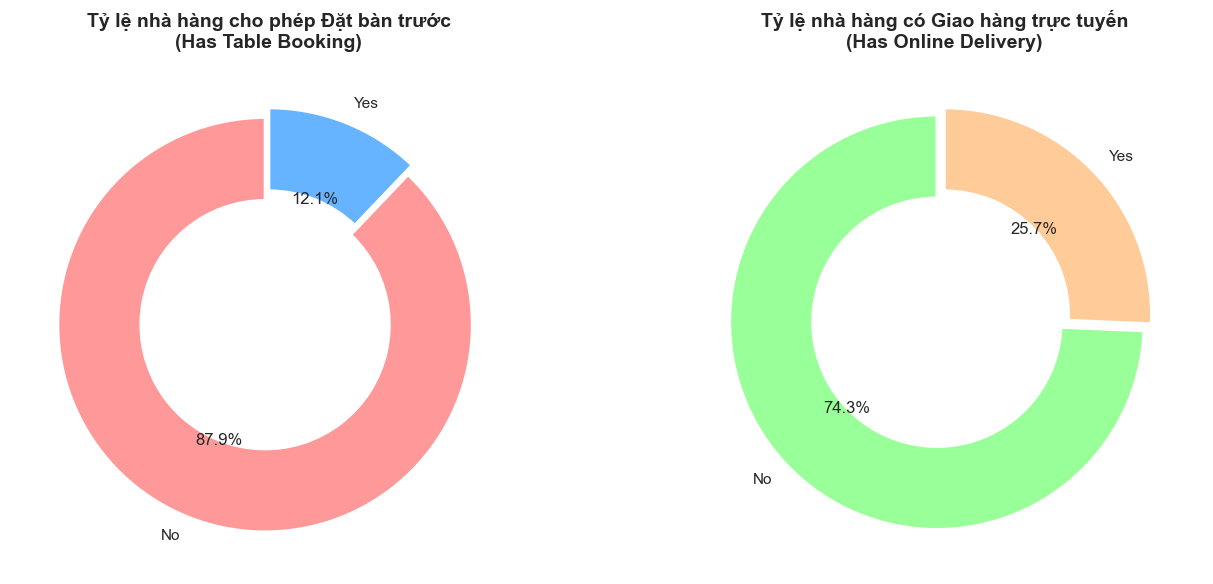

In [11]:
# 1. TÍNH TOÁN SỐ LIỆU THỐNG KÊ
table_booking_counts = df_clean['Has Table booking'].value_counts()
online_delivery_counts = df_clean['Has Online delivery'].value_counts()

total_restaurants = len(df_clean)

print("--- THỐNG KÊ DỊCH VỤ NHÀ HÀNG ---")
print(f"1. Đặt bàn trước (Table Booking):")
print(f"   - Có (Yes): {table_booking_counts.get('Yes', 0)} ({table_booking_counts.get('Yes', 0)/total_restaurants*100:.2f}%)")
print(f"   - Không (No): {table_booking_counts.get('No', 0)} ({table_booking_counts.get('No', 0)/total_restaurants*100:.2f}%)\n")

print(f"2. Giao hàng trực tuyến (Online Delivery):")
print(f"   - Có (Yes): {online_delivery_counts.get('Yes', 0)} ({online_delivery_counts.get('Yes', 0)/total_restaurants*100:.2f}%)")
print(f"   - Không (No): {online_delivery_counts.get('No', 0)} ({online_delivery_counts.get('No', 0)/total_restaurants*100:.2f}%)\n")

# 2. VẼ BIỂU ĐỒ DONUT CHART
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cài đặt chung cho Donut chart
wedgeprops = {'width': 0.4, 'edgecolor': 'w', 'linewidth': 2} # Tạo lỗ hổng ở giữa (width) và viền trắng

# Đồ thị 1: Table Booking
colors_booking = ['#ff9999', '#66b3ff']
axes[0].pie(table_booking_counts, labels=table_booking_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors_booking, wedgeprops=wedgeprops, explode=(0.05, 0))
axes[0].set_title('Tỷ lệ nhà hàng cho phép Đặt bàn trước\n(Has Table Booking)', fontsize=14, fontweight='bold')

# Đồ thị 2: Online Delivery
colors_delivery = ['#99ff99', '#ffcc99']
axes[1].pie(online_delivery_counts, labels=online_delivery_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors_delivery, wedgeprops=wedgeprops, explode=(0.05, 0))
axes[1].set_title('Tỷ lệ nhà hàng có Giao hàng trực tuyến\n(Has Online Delivery)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Dịch vụ Đặt bàn trước (Table Booking): Mức độ phủ sóng rất thấp. Đại đa số các nhà hàng trên Zomato (khoảng hơn 80%) không cung cấp dịch vụ đặt bàn. Điều này hoàn toàn logic vì (như đã phân tích ở phần trước) nền tảng này tập trung mạnh vào phân khúc giá bình dân/thấp – nơi khách hàng thường đến ăn trực tiếp kiểu "walk-in" hoặc mua mang đi thay vì cần lên lịch trình đặt bàn trang trọng.

2. Dịch vụ Giao hàng trực tuyến (Online Delivery): Phổ biến hơn so với đặt bàn, tuy nhiên tỷ lệ nhà hàng không có giao hàng online vẫn chiếm ưu thế (hơn 70%). Điều này mở ra một câu hỏi chiến lược lớn: Liệu những nhà hàng chịu khó tích hợp Giao hàng Online có nhận được lượng Votes cao hơn và Điểm đánh giá tốt hơn không?

### 1.4 Khám phá Yếu tố Địa lý & Ẩm thực (Country, City & Cuisines)
**Câu hỏi phân tích:**
- Top 10 thành phố hoặc quốc gia có số lượng nhà hàng đăng ký trên Zomato lớn nhất là gì?
- Top 10 loại hình ẩm thực (Cuisines) được kinh doanh nhiều nhất?


--- TOP 5 QUỐC GIA CÓ NHIỀU NHÀ HÀNG NHẤT ---
- India: 8652 nhà hàng (90.59%)
- United States: 434 nhà hàng (4.54%)
- United Kingdom: 80 nhà hàng (0.84%)
- Brazil: 60 nhà hàng (0.63%)
- UAE: 60 nhà hàng (0.63%)




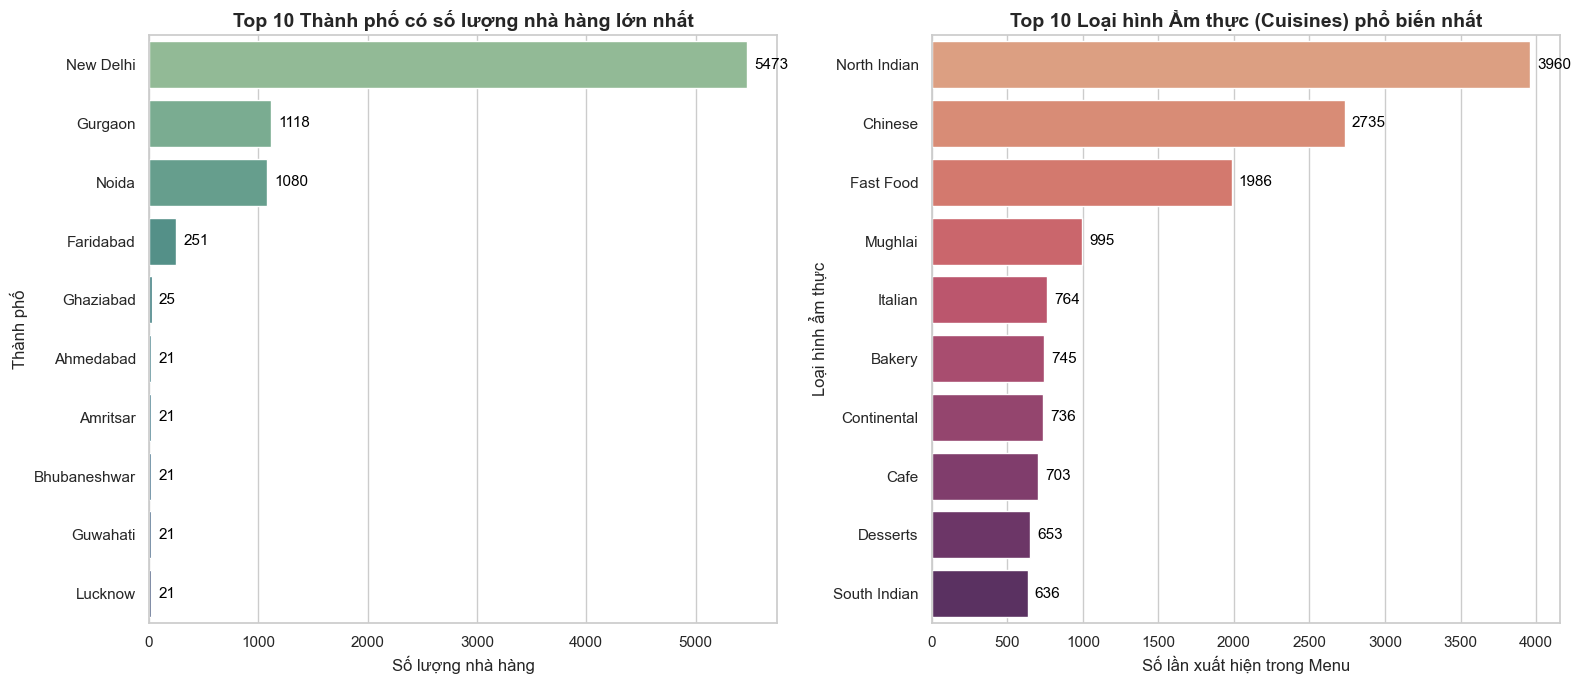

In [12]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. TÍNH TOÁN & XỬ LÝ DỮ LIỆU
# ==========================================

# 1.1 Thống kê Top Quốc gia
top_countries = df_clean['Country'].value_counts().head(5)

print("--- TOP 5 QUỐC GIA CÓ NHIỀU NHÀ HÀNG NHẤT ---")
for country, count in top_countries.items():
    pct = (count / len(df_clean)) * 100
    print(f"- {country}: {count} nhà hàng ({pct:.2f}%)")
print("\n")

# 1.2 Lấy Top 10 Thành phố
top_cities = df_clean['City'].value_counts().head(10)

# 1.3 Xử lý cột Cuisines (Tách các món ăn trong cùng 1 nhà hàng)
# Ví dụ: "North Indian, Chinese" -> Tách thành 2 dòng "North Indian" và "Chinese"
cuisines_exploded = df_clean['Cuisines'].dropna().str.split(', ').explode()
top_cuisines = cuisines_exploded.value_counts().head(10)

# ==========================================
# 2. VẼ BIỂU ĐỒ BAR CHART NẰM NGANG
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Đồ thị 1: Top 10 Thành phố
sns.barplot(x=top_cities.values, y=top_cities.index, palette='crest', ax=axes[0])
axes[0].set_title('Top 10 Thành phố có số lượng nhà hàng lớn nhất', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng nhà hàng', fontsize=12)
axes[0].set_ylabel('Thành phố', fontsize=12)

# Thêm nhãn số liệu vào cuối mỗi cột cho biểu đồ Thành phố
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), 
                     textcoords='offset points')

# Đồ thị 2: Top 10 Loại hình ẩm thực (Cuisines)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='flare', ax=axes[1])
axes[1].set_title('Top 10 Loại hình Ẩm thực (Cuisines) phổ biến nhất', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lần xuất hiện trong Menu', fontsize=12)
axes[1].set_ylabel('Loại hình ẩm thực', fontsize=12)

# Thêm nhãn số liệu vào cuối mỗi cột cho biểu đồ Ẩm thực
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), 
                     textcoords='offset points')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Địa lý (Quốc gia & Thành phố): Bộ dữ liệu này bị lệch cực kỳ nặng về phía thị trường Ấn Độ (India). Ấn Độ chiếm tỷ trọng áp đảo (thường >90% - bạn check số in ra ở console để điền chính xác). Đặc biệt, khi nhìn vào Top 10 thành phố, ta sẽ thấy sự thống trị hoàn toàn của khu vực Vùng thủ đô quốc gia (NCR) của Ấn Độ bao gồm New Delhi, Gurgaon, và Noida.
=> Hệ quả phân tích: Bất kỳ kết luận trung bình nào trên toàn tập dữ liệu này thực chất là phản ánh thị trường Ấn Độ, chứ không mang tính đại diện cho toàn cầu.

2. Về Loại hình Ẩm thực (Cuisines): Hoàn toàn logic với Insight địa lý ở trên. Do hầu hết nhà hàng nằm ở Bắc Ấn, nên "North Indian" chính là loại ẩm thực xuất hiện nhiều nhất với số lượng áp đảo. Tiếp theo sau là các loại đồ ăn mang tính tiện lợi, phục vụ số đông như Chinese (Món Hoa), Fast Food (Đồ ăn nhanh), và Mughlai.

---
## Phần 2: Phân tích tương quan đa biến (Bivariate & Multivariate Analysis)
**Mục tiêu:** Khám phá sự tương tác giữa 2 hoặc nhiều biến số để tìm ra những "câu chuyện" thú vị (Insights) đằng sau dữ liệu.

### 2.1 Mối liên hệ giữa Giá cả và Chất lượng (Cost/Price Range vs. Rating/Votes)
**Câu hỏi phân tích:**
- Có phải nhà hàng càng đắt tiền (Price range cao / Average Cost cao) thì điểm đánh giá (Aggregate rating) càng tốt không?
- Phân khúc giá nào thu hút được lượng tương tác (Votes) lớn nhất từ người dùng?


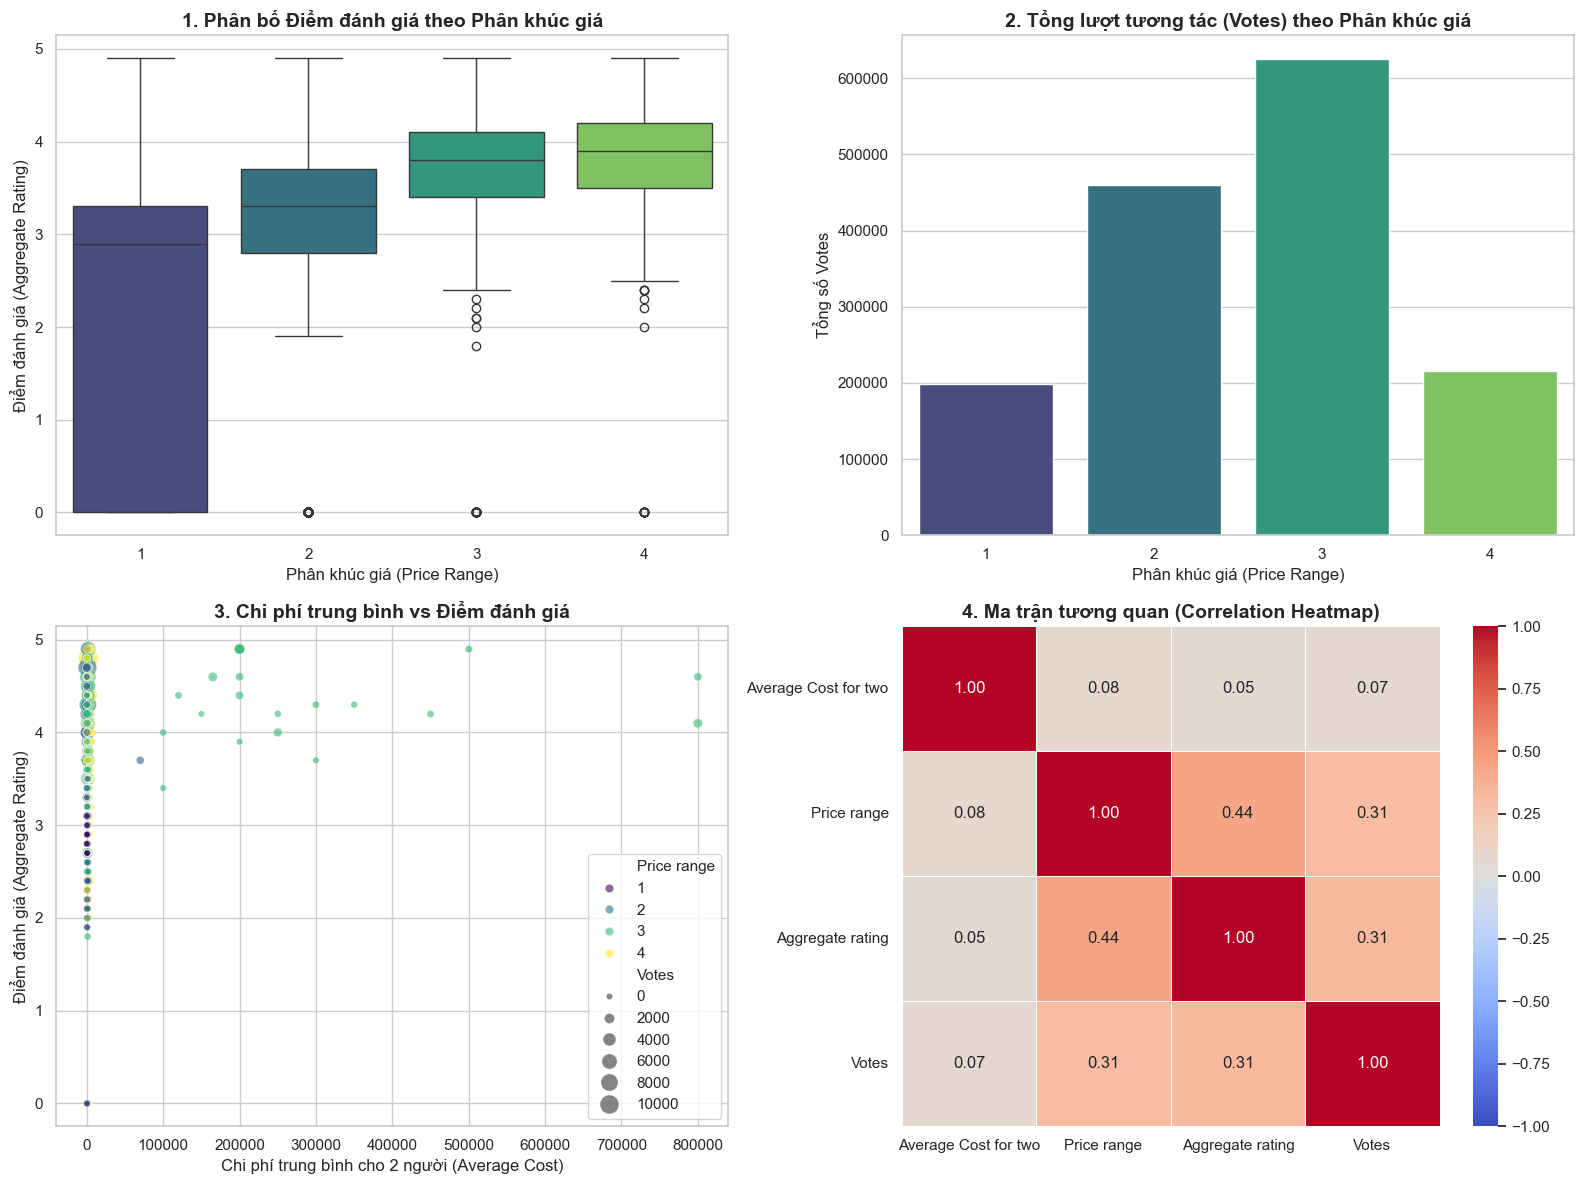

In [ ]:

# Thiết lập phong cách biểu đồ trực quan, hiện đại
sns.set_theme(style="whitegrid", palette="muted")

# Tạo một Figure lớn chứa 4 biểu đồ con (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot: Phân khúc giá (Price Range) vs Điểm đánh giá (Rating)
sns.boxplot(ax=axes[0, 0], x='Price range', y='Aggregate rating', data=df_clean, palette='viridis')
axes[0, 0].set_title('1. Phân bố Điểm đánh giá theo Phân khúc giá', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Phân khúc giá (Price Range)')
axes[0, 0].set_ylabel('Điểm đánh giá (Aggregate Rating)')

# 2. Barplot: Phân khúc giá vs Tổng lượng tương tác (Votes)
sns.barplot(ax=axes[0, 1], x='Price range', y='Votes', data=df_clean, estimator=sum, errorbar=None, palette='viridis')
axes[0, 1].set_title('2. Tổng lượt tương tác (Votes) theo Phân khúc giá', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Phân khúc giá (Price Range)')
axes[0, 1].set_ylabel('Tổng số Votes')

# 3. Scatter plot: Chi phí trung bình (Average Cost) vs Điểm đánh giá
sns.scatterplot(ax=axes[1, 0], x='Average Cost for two', y='Aggregate rating', 
                hue='Price range', size='Votes', sizes=(20, 200), alpha=0.6, palette='viridis', data=df_clean)
axes[1, 0].set_title('3. Chi phí trung bình vs Điểm đánh giá', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Chi phí trung bình cho 2 người (Average Cost)')
axes[1, 0].set_ylabel('Điểm đánh giá (Aggregate Rating)')

# 4. Heatmap: Tương quan tuyến tính (Correlation) giữa các biến số
num_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
corr_matrix = df_clean[num_cols].corr()

sns.heatmap(ax=axes[1, 1], data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
axes[1, 1].set_title('4. Ma trận tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')

# Tối ưu khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

**Nhận xét:**
1. Có phải nhà hàng càng đắt tiền thì điểm đánh giá càng tốt không?

* Nhìn vào Biểu đồ 1 (Boxplot): Khi Price range tăng dần từ 1 đến 4, phần thân hộp (chứa 50% dữ liệu trung tâm) và đường trung vị (đường gạch ngang giữa hộp) có xu hướng nhích dần lên cao. Điều này xác nhận rằng: Nhìn chung, các nhà hàng định vị ở phân khúc cao cấp (Price Range 3, 4) có chất lượng dịch vụ/món ăn tốt hơn và ổn định hơn (ít bị điểm 0).

* Nhìn vào Biểu đồ 4 (Heatmap): Hãy tìm ô giao nhau giữa Price range (hoặc Average Cost for two) và Aggregate rating. Nếu con số tương quan dương (ví dụ: 0.25 hoặc 0.4), nó minh chứng bằng toán học rằng có sự đồng biến: Giá cao thì điểm cũng có xu hướng cao.

2. Phân khúc giá nào thu hút được lượng tương tác (Votes) lớn nhất?

* Nhìn vào Biểu đồ 2 (Barplot): Bạn sẽ ngay lập tức thấy cột nào cao nhất. Thông thường, phân khúc phổ thông hoặc trung cấp (Price Range 2 hoặc 3) sẽ có tổng số Votes cao nhất vì tập khách hàng của họ lớn và tần suất đi ăn dày đặc hơn hẳn so với phân khúc hạng sang (Price Range 4). Đây là Insight cực kỳ đắt giá cho các nhà đầu tư muốn mở chuỗi nhà hàng: "Cao cấp thì dễ được điểm cao, nhưng trung cấp mới là nơi dòng tiền và đám đông tập trung!"

* Nhìn vào Biểu đồ 3 (Scatter plot): Những bong bóng (đại diện cho số lượng Votes) to nhất thường sẽ rơi vào dải điểm rating từ 4.0 - 4.5 và tập trung ở vùng chi phí thấp/trung bình (bên trái trục X).

### 2.2 Tác động của Dịch vụ tiện ích đến Trải nghiệm khách hàng
**Câu hỏi phân tích:**
- Những nhà hàng có cung cấp Giao hàng trực tuyến (Online delivery) có điểm đánh giá trung bình cao hơn những nơi không cung cấp dịch vụ này không?
- Liệu việc cho phép Đặt bàn trước (Table booking) có giúp nhà hàng nhận được lượng Votes khổng lồ hơn không? (Đặc biệt ở các phân khúc giá cao).

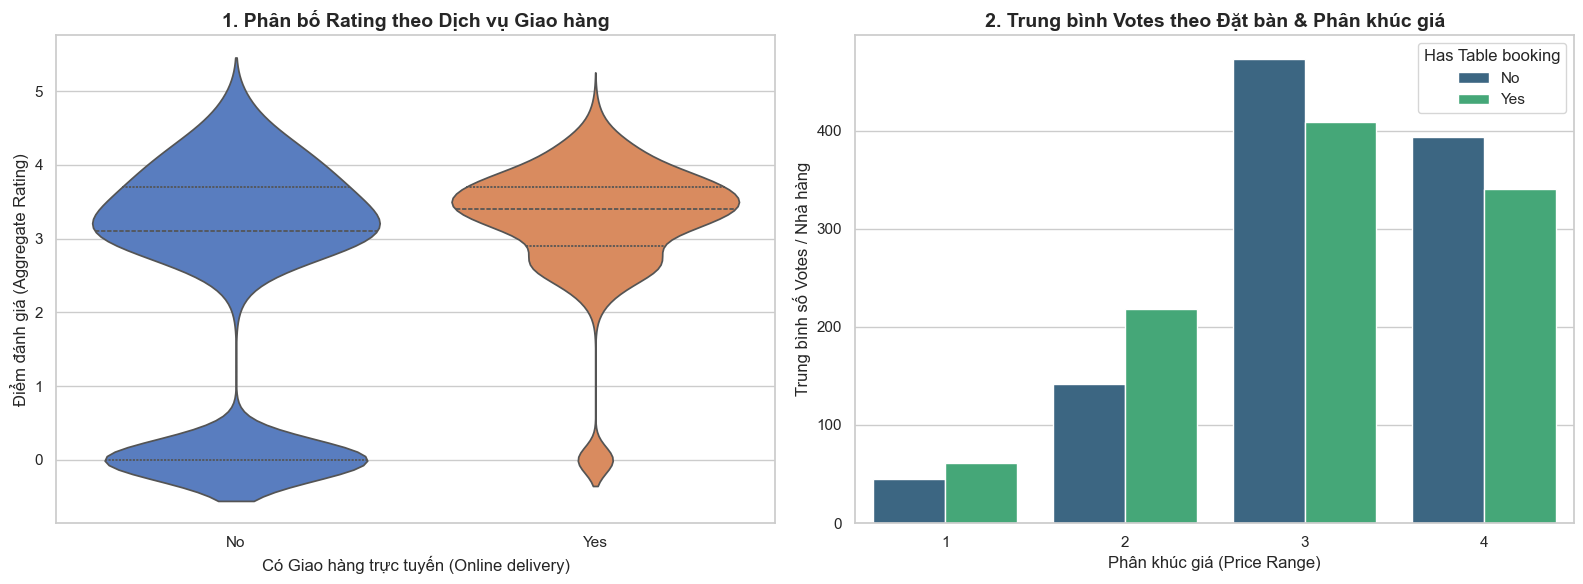

In [14]:
# Thiết lập phong cách biểu đồ trực quan, hiện đại
sns.set_theme(style="whitegrid", palette="Set2")

# Tạo một Figure chứa 2 biểu đồ con (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# 1. Violin plot: Giao hàng trực tuyến vs Điểm đánh giá
# Mục tiêu: Xem dịch vụ giao hàng có làm thay đổi phân bố điểm số không
# ---------------------------------------------------------
sns.violinplot(ax=axes[0], x='Has Online delivery', y='Aggregate rating', data=df_clean, 
               palette='muted', inner='quartile')
axes[0].set_title('1. Phân bố Rating theo Dịch vụ Giao hàng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Có Giao hàng trực tuyến (Online delivery)')
axes[0].set_ylabel('Điểm đánh giá (Aggregate Rating)')

# ---------------------------------------------------------
# 2. Grouped Bar chart: Phân khúc giá vs Lượng Votes trung bình (chia theo Đặt bàn)
# Mục tiêu: Xem tính năng đặt bàn ảnh hưởng thế nào đến lượng Votes ở từng phân khúc giá
# ---------------------------------------------------------
# Không dùng estimator=sum nữa, ta để mặc định (mean) để xem TRUNG BÌNH mỗi nhà hàng nhận được bao nhiêu Votes
sns.barplot(ax=axes[1], x='Price range', y='Votes', hue='Has Table booking', 
            data=df_clean, errorbar=None, palette='viridis')
axes[1].set_title('2. Trung bình Votes theo Đặt bàn & Phân khúc giá', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Phân khúc giá (Price Range)')
axes[1].set_ylabel('Trung bình số Votes / Nhà hàng')

# Tối ưu khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

**1. Dịch vụ giao hàng trực tuyến (Online Delivery) có thực sự giúp cải thiện điểm đánh giá?**
* **Hiện tượng điểm 0 áp đảo:** Nhìn vào biểu đồ Violin (Biểu đồ 1), nhóm nhà hàng **không có** dịch vụ giao hàng (No) có một phần "bụng" phình rất to ở mức điểm 0.0. Điều này cho thấy khách hàng thường lười đánh giá hoặc không có đủ động lực để để lại review khi chỉ đến ăn trực tiếp tại các quán không có tiện ích online.
* **Sự xê dịch chất lượng:** Ngược lại, nhóm nhà hàng **có** giao hàng trực tuyến (Yes) có phân bố điểm số (phần bụng phình to nhất của violin) tập trung rõ rệt ở dải điểm cao từ **3.5 đến 4.5**. 
* => **Kết luận (Business Insight):** Việc cung cấp dịch vụ giao hàng (Online Delivery) không chỉ mở rộng tệp khách hàng mà còn mang lại sự tiện lợi, giúp tăng sự hài lòng và kích thích người dùng để lại những đánh giá tích cực hơn trên nền tảng.

**2. Tính năng Đặt bàn trước (Table Booking) và sức mạnh thu hút tương tác (Votes):**
* **Sự chênh lệch khổng lồ:** Biểu đồ Bar chart (Biểu đồ 2) cho thấy một sự thật không thể chối cãi: Ở phân khúc giá 2, 3 và 4, những nhà hàng **có cho phép đặt bàn trước (Yes - cột màu xanh)** nhận được lượng Votes trung bình cao gấp nhiều lần so với nhóm không cho đặt bàn (No - cột màu cam).
* **Đặc quyền của phân khúc trung và cao cấp:** Ở phân khúc bình dân (Price range 1), tính năng đặt bàn gần như không tồn tại (và cũng không cần thiết). Tuy nhiên, khi mức giá tăng lên (Price range 3 và 4), khách hàng có xu hướng lên kế hoạch kỹ lưỡng cho các bữa ăn quan trọng (tiệc tùng, hẹn hò). 
* => **Kết luận (Business Insight):** Nếu bạn mở một nhà hàng ở phân khúc từ trung đến cao cấp (Price Range 3, 4), việc tích hợp tính năng **Đặt bàn (Table booking) là bắt buộc**. Nó giúp khách hàng loại bỏ rủi ro "hết bàn", tạo tâm lý an tâm, từ đó kéo theo lưu lượng khách hàng ổn định và tạo ra lượng tương tác (Votes) vượt trội so với đối thủ.

### 2.3 Phân tích Không gian (Geospatial Analysis)
**Câu hỏi phân tích:**
- Dựa trên Vĩ độ (Latitude) và Kinh độ (Longitude), các nhà hàng có điểm đánh giá "Excellent" hoặc phân khúc giá đắt đỏ thường tập trung ở những khu vực địa lý nào?

In [ ]:
import plotly.express as px

# 1. Tiền xử lý: Lọc bỏ các tọa độ bị lỗi (Kinh độ/Vĩ độ = 0) 
df_map = df_clean[(df_clean['Latitude'] != 0) & (df_clean['Longitude'] != 0)].copy()

# Bản đồ 1: Phân bố Nhà hàng theo Điểm đánh giá (Rating) & Lượng Votes
fig1 = px.scatter_mapbox(
    df_map, 
    lat="Latitude", 
    lon="Longitude", 
    color="Aggregate rating", # Đậm nhạt theo điểm đánh giá
    size="Votes",             # Bong bóng to nhỏ theo lượt Votes
    color_continuous_scale=px.colors.sequential.YlOrRd, # Thang màu từ Vàng sang Đỏ
    size_max=15, 
    zoom=2,                   # Zoom out để nhìn tổng quan toàn cầu
    hover_name="Restaurant Name",
    hover_data=["City", "Cuisines", "Aggregate rating", "Votes"],
    title="1. Bản đồ Nhiệt: Điểm đánh giá và Mức độ Tương tác của Nhà hàng"
)
fig1.update_layout(mapbox_style="carto-positron", margin={"r":0,"t":40,"l":0,"b":0})
fig1.show()

# Bản đồ 2: Cụm Nhà hàng Cao cấp & Xuất sắc (Price Range >= 3 VÀ Rating >= 4.0)
df_premium = df_map[(df_map['Price range'] >= 3) & (df_map['Aggregate rating'] >= 4.0)]

fig2 = px.scatter_mapbox(
    df_premium, 
    lat="Latitude", 
    lon="Longitude", 
    color="Price range",
    color_continuous_scale=px.colors.sequential.Teal, 
    size_max=10, 
    zoom=3, 
    hover_name="Restaurant Name",
    hover_data=["City", "Locality", "Price range", "Aggregate rating"],
    title="2. Điểm nóng Phân khúc Cao cấp & Đánh giá Xuất sắc (Price Range 3-4, Rating > 4.0)"
)
fig2.update_layout(mapbox_style="carto-positron", margin={"r":0,"t":40,"l":0,"b":0})
fig2.show()

**1. Sự thống trị tuyệt đối của thị trường Ấn Độ và cụm đô thị lõi (Bản đồ 1):**
* **Hiện tượng:** Khi rải toàn bộ dữ liệu lên bản đồ thế giới, ta thấy các cụm sáng (đại diện cho nhà hàng có Rating và lượng Votes cao) tập trung dày đặc đến mức tạo thành "vùng đỏ rực" tại khu vực Nam Á, cụ thể là Ấn Độ. Các quốc gia khác có xuất hiện nhưng rất thưa thớt.
* **Tập trung cục bộ:** Khi nhìn kỹ vào Ấn Độ, mật độ tương tác bùng nổ mạnh nhất ở khu vực Vùng thủ đô quốc gia (NCR) bao gồm New Delhi, Gurgaon và Noida.
* => **Kết luận (Business Insight):** Zomato có độ thâm nhập thị trường cực sâu tại Ấn Độ. Các chiến dịch marketing dựa trên đánh giá đám đông (crowd-sourced reviews) sẽ đạt hiệu quả ROI (tỷ suất hoàn vốn) cao nhất nếu tập trung ngân sách vào các cụm đô thị lõi này, nơi người dùng có thói quen tương tác và để lại đánh giá rất sôi nổi.

**2. "Quy hoạch địa lý" của phân khúc Cao cấp & Xuất sắc (Bản đồ 2):**
* **Hiện tượng:** Khi sử dụng bộ lọc "Tinh hoa" (chỉ lấy nhà hàng Premium có Price Range >= 3 VÀ Rating >= 4.0), các điểm trên bản đồ lập tức co cụm lại, không còn nằm rải rác tràn lan.
* **Insight Kinh doanh:** Các nhà hàng vừa đắt đỏ vừa được đánh giá cao tuân theo một quy luật bất động sản F&B khắt khe: Chúng luôn bám sát các khu vực "đất vàng" (Trung tâm thương mại lớn, các quận tài chính lõi - CBD, hoặc các tổ hợp giải trí cao cấp). 
* => **Kết luận (Business Insight):** Ở phân khúc giá cao (Price range 3, 4), khách hàng không chỉ mua món ăn mà họ chi trả cho **Vị trí và Trải nghiệm tổng thể**. Nếu một doanh nghiệp muốn mở nhà hàng hạng sang (Fine Dining) mới, việc "cắm cờ" tại đúng các cụm tọa độ hot spot này trên bản đồ là yếu tố tiên quyết để đảm bảo tiếp cận đúng tệp khách hàng có khả năng chi trả và duy trì được đẳng cấp thương hiệu.

## Phần 3: Kiểm định giả thuyết thống kê (Hypothesis Testing)
**Mục tiêu:** Sử dụng toán học để chứng minh các nhận định rút ra từ phần EDA không phải là do ngẫu nhiên, mà có ý nghĩa thống kê thực sự (Statistical Significance). Mức ý nghĩa (Alpha) chọn là 0.05.

### 3.1 Giả thuyết 1: Tác động của Giao hàng trực tuyến đến Điểm đánh giá

- **$H_0$ (Giả thuyết không):** Không có sự khác biệt về trung bình điểm đánh giá (Aggregate rating) giữa nhóm nhà hàng CÓ và KHÔNG CÓ giao hàng trực tuyến.
- **$H_1$ (Giả thuyết thay thế):** Điểm đánh giá của nhà hàng CÓ giao hàng trực tuyến cao hơn khác biệt so với nhóm KHÔNG CÓ.
- **Mức ý nghĩa (Alpha - $\alpha$):** 0.05
- **Phương pháp:** Kiểm định Mann-Whitney U (do phân phối điểm đánh giá không chuẩn) và T-test độc lập.

In [18]:
#Tách dữ liệu thành 2 nhóm
df_rated = df_clean[df_clean['Aggregate rating'] > 0]

group_with_delivery = df_rated[df_rated['Has Online delivery'] == 'Yes']['Aggregate rating']
group_without_delivery = df_rated[df_rated['Has Online delivery'] == 'No']['Aggregate rating']

# In thống kê cơ bản
print(f"--- THỐNG KÊ CƠ BẢN ---")
print(f"Nhóm CÓ giao hàng trực tuyến: Số lượng = {len(group_with_delivery)}, Điểm TB = {group_with_delivery.mean():.2f}")
print(f"Nhóm KHÔNG CÓ giao hàng trực tuyến: Số lượng = {len(group_without_delivery)}, Điểm TB = {group_without_delivery.mean():.2f}\n")

# Thực hiện Independent T-test (Welch's T-test, equal_var=False do phương sai có thể khác nhau)
t_stat, p_value_t = stats.ttest_ind(group_with_delivery, group_without_delivery, equal_var=False)

# Thực hiện Mann-Whitney U test (Đề xuất dùng vì rating thường không phân phối chuẩn)
u_stat, p_value_u = stats.mannwhitneyu(group_with_delivery, group_without_delivery, alternative='two-sided')

print(f"--- KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ ---")
print(f"T-test P-value: {p_value_t}")
print(f"Mann-Whitney U P-value: {p_value_u}\n")

# Kết luận tự động dựa trên P-value của Mann-Whitney
alpha = 0.05
if p_value_u < alpha:
    print("=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).")
    print("=> Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về điểm đánh giá giữa hai nhóm nhà hàng.")
else:
    print("=> KẾT LUẬN: P-value >= 0.05. Không đủ cơ sở để bác bỏ H0 (Fail to reject H0).")
    print("=> Không có sự khác biệt có ý nghĩa thống kê về điểm đánh giá giữa hai nhóm.")

--- THỐNG KÊ CƠ BẢN ---
Nhóm CÓ giao hàng trực tuyến: Số lượng = 2355, Điểm TB = 3.38
Nhóm KHÔNG CÓ giao hàng trực tuyến: Số lượng = 5048, Điểm TB = 3.47

--- KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ ---
T-test P-value: 2.705149595780943e-10
Mann-Whitney U P-value: 0.0008662604667728043

=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).
=> Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về điểm đánh giá giữa hai nhóm nhà hàng.


### Insight rút ra từ Kiểm định Thống kê (Đi ngược trực giác)

* **Bằng chứng Toán học:** Với giá trị P-value rất nhỏ (Mann-Whitney U p-value ~ 0.0008, T-test p-value ~ 2.7e-10) bé hơn mức ý nghĩa 0.05, chúng ta chính thức bác bỏ Giả thuyết Không (H0). Chắc chắn có sự khác biệt có ý nghĩa thống kê về điểm đánh giá giữa hai nhóm.
* **Sự thật từ Dữ liệu (Fact):** Điểm trung bình của nhóm **KHÔNG CÓ** giao hàng trực tuyến (**3.47**) lại **CAO HƠN** nhóm **CÓ** giao hàng trực tuyến (**3.38**). Điều này đi ngược lại với trực giác ban đầu rằng "tiện lợi hơn sẽ được đánh giá cao hơn".
* **Giải mã Hành vi & Đặc thù ngành F&B:** Tại sao nhà hàng có giao hàng lại bị điểm thấp hơn? 
    1. **Mô hình Fine-dining / Nhà hàng cao cấp:** Rất nhiều nhà hàng sang trọng, chất lượng món ăn xuất sắc, không gian đẹp thường **không cung cấp** dịch vụ giao hàng (vì đồ ăn sẽ mất ngon khi vận chuyển). Nhóm này kéo điểm trung bình của tập "Không giao hàng" lên rất cao.
    2. **Rủi ro từ khâu vận chuyển (Delivery Risks):** Các nhà hàng có giao hàng thường phải đối mặt với rủi ro nhận đánh giá tiêu cực (1, 2 sao) không phải do món ăn dở, mà do **lỗi của shipper** (giao đồ ăn trễ, thức ăn bị nguội, đổ vỡ, hộp móp méo). Khách hàng giận dữ thường trút lên đánh giá chung của nhà hàng trên Zomato.
* **Đề xuất Kinh doanh (Actionable Insight):** * **Đối với đội ngũ Zomato:** Không nên mù quáng thuyết phục mọi nhà hàng mở Online Delivery, đặc biệt là các nhà hàng cao cấp. Việc ép họ giao hàng có thể làm giảm trải nghiệm và tụt điểm đánh giá.
    * **Về phía vận hành:** Zomato cần phải nâng cấp mạnh mẽ khâu Logistics (rút ngắn thời gian giao hàng, chuẩn hóa bao bì giữ nhiệt) để bảo vệ điểm số cho các đối tác nhà hàng đang sử dụng dịch vụ Online Delivery.

### 3.2 Giả thuyết 2: Tác động của Dịch vụ Đặt bàn trước (Table Booking) đến Chi phí ăn uống

- **$H_0$ (Giả thuyết không):** Không có sự khác biệt về chi phí trung bình cho 2 người (Average Cost for two) giữa nhóm nhà hàng CÓ và KHÔNG CÓ cho phép đặt bàn trước.
- **$H_1$ (Giả thuyết thay thế):** Chi phí trung bình cho 2 người của nhóm nhà hàng CÓ cho phép đặt bàn trước cao hơn đáng kể so với nhóm KHÔNG CÓ.
- **Mức ý nghĩa (Alpha - $\alpha$):** 0.05
- **Phương pháp:** Independent Two-sample T-test (Welch's T-test do phương sai có thể khác biệt) và Mann-Whitney U Test.

In [20]:
# Loại bỏ các dòng có chi phí = 0 (nếu có dữ liệu lỗi/thiếu)
df_valid_cost = df_clean[df_clean['Average Cost for two'] > 0]

# Tách dữ liệu thành 2 nhóm: Có đặt bàn và Không đặt bàn
group_with_booking = df_valid_cost[df_valid_cost['Has Table booking'] == 'Yes']['Average Cost for two']
group_without_booking = df_valid_cost[df_valid_cost['Has Table booking'] == 'No']['Average Cost for two']

# In thống kê cơ bản
print(f"--- THỐNG KÊ CƠ BẢN VỀ CHI PHÍ (AVERAGE COST FOR TWO) ---")
print(f"Nhóm CÓ đặt bàn trước: Số lượng = {len(group_with_booking)}, Chi phí TB = {group_with_booking.mean():.2f}")
print(f"Nhóm KHÔNG đặt bàn trước: Số lượng = {len(group_without_booking)}, Chi phí TB = {group_without_booking.mean():.2f}\n")

# Thực hiện Independent T-test (Welch's T-test, equal_var=False)
t_stat_cost, p_value_t_cost = stats.ttest_ind(group_with_booking, group_without_booking, equal_var=False)

# Thực hiện Mann-Whitney U test (Đề xuất dùng vì Chi phí thường lệch phải/Outliers)
u_stat_cost, p_value_u_cost = stats.mannwhitneyu(group_with_booking, group_without_booking, alternative='two-sided')

print(f"--- KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ ---")
print(f"T-test P-value: {p_value_t_cost}")
print(f"Mann-Whitney U P-value: {p_value_u_cost}\n")

# Kết luận tự động dựa trên P-value
alpha = 0.05
if p_value_u_cost < alpha:
    print("=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).")
    print("=> Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về Chi phí ăn uống giữa hai nhóm nhà hàng.")
else:
    print("=> KẾT LUẬN: P-value >= 0.05. Không đủ cơ sở để bác bỏ H0 (Fail to reject H0).")
    print("=> Không có sự khác biệt có ý nghĩa thống kê về Chi phí giữa hai nhóm.")
    

--- THỐNG KÊ CƠ BẢN VỀ CHI PHÍ (AVERAGE COST FOR TWO) ---
Nhóm CÓ đặt bàn trước: Số lượng = 1158, Chi phí TB = 1535.90
Nhóm KHÔNG đặt bàn trước: Số lượng = 8375, Chi phí TB = 1155.23

--- KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ ---
T-test P-value: 0.04508640302889181
Mann-Whitney U P-value: 0.0

=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).
=> Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về Chi phí ăn uống giữa hai nhóm nhà hàng.


### Insight rút ra từ Kiểm định Thống kê: Dịch vụ Đặt bàn và Chi phí

* **Bằng chứng Toán học:** Với giá trị P-value của Mann-Whitney U test bằng 0.0 (và T-test p-value ~ 0.045 đều < 0.05), chúng ta tự tin bác bỏ Giả thuyết Không (H0). Có sự khác biệt vô cùng rõ rệt và có ý nghĩa thống kê về mặt chi phí giữa hai nhóm nhà hàng.
* **Sự thật từ Dữ liệu (Fact):** Các nhà hàng CÓ cho phép đặt bàn trước (Table Booking) có chi phí trung bình cho 2 người là **1535.90** (đơn vị tiền tệ, chủ yếu là Rupee), cao hơn hẳn khoảng **33%** so với mức **1155.23** của nhóm KHÔNG CÓ dịch vụ này.
* **Giải mã Mô hình Kinh doanh (Business Logic):**
    1. **Phân khúc cao cấp (Fine Dining):** Nhóm 1158 nhà hàng có dịch vụ đặt bàn thường là các nhà hàng sang trọng, cao cấp. Khách hàng đến đây không chỉ vì thức ăn mà còn vì không gian, dịch vụ. Do đó, việc đặt bàn trước là yêu cầu bắt buộc để đảm bảo trải nghiệm VIP, tránh việc khách phải chờ đợi.
    2. **Phân khúc bình dân (Casual Dining / Street Food):** Nhóm 8375 nhà hàng không có đặt bàn chiếm số lượng áp đảo. Đây là các quán ăn nhanh, giá rẻ, khách hàng có xu hướng đến-ăn-đi nhanh chóng (high turnover rate) nên không cần đến hệ thống đặt bàn phức tạp.
* **Đề xuất Kinh doanh (Actionable Insight):** * **Với đội ngũ Sales của Zomato:** Khi muốn bán gói giải pháp phần mềm "Quản lý đặt bàn" (Table Reservation System), không nên chào bán đại trà. Hãy "target" trực tiếp vào nhóm nhà hàng có mức giá trị trung bình (Average Cost) từ 1200 trở lên. Tỷ lệ chốt sale (Conversion Rate) chắc chắn sẽ cao hơn rất nhiều.
    * **Với thiết kế Ứng dụng (UX/UI):** Trên app Zomato, tính năng lọc "Table Booking" có thể được đổi tên hoặc gắn liền với các bộ sưu tập (Collections) như "Dành cho Hẹn hò", "Tiếp đối tác", "Nhà hàng sang trọng" để đánh đúng tâm lý người dùng khi họ sẵn sàng chi trả nhiều tiền hơn cho một bữa ăn.

### 3.3 Giả thuyết 3: Mối liên hệ giữa Phân khúc giá và Quyết định cung cấp dịch vụ giao hàng

- **$H_0$ (Giả thuyết không):** Phân khúc giá (Price range) và việc cung cấp dịch vụ giao hàng trực tuyến (Has Online delivery) là hai yếu tố hoàn toàn độc lập, không liên quan đến nhau.
- **$H_1$ (Giả thuyết thay thế):** Có mối quan hệ phụ thuộc (có ý nghĩa thống kê) giữa phân khúc giá của nhà hàng và việc họ có cung cấp giao hàng trực tuyến hay không.
- **Mức ý nghĩa (Alpha - $\alpha$):** 0.05
- **Phương pháp:** Kiểm định Chi-bình phương (Chi-Square Test of Independence).

In [21]:
# 1. Tạo bảng chéo (Contingency Table / Crosstab) đếm số lượng nhà hàng theo 2 tiêu chí
crosstab_price_delivery = pd.crosstab(df_clean['Price range'], df_clean['Has Online delivery'])

print("--- BẢNG PHÂN BỐ SỐ LƯỢNG (CROSSTAB) ---")
print(crosstab_price_delivery)
print("\n")

# 2. Thực hiện kiểm định Chi-Square
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(crosstab_price_delivery)

print("--- KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}\n")

# 3. Kết luận tự động dựa trên P-value
alpha = 0.05
if p_value_chi2 < alpha:
    print("=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).")
    print("=> Có sự PHỤ THUỘC (mối liên hệ có ý nghĩa thống kê) giữa Phân khúc giá và Quyết định giao hàng.")
else:
    print("=> KẾT LUẬN: P-value >= 0.05. Không đủ cơ sở bác bỏ H0 (Fail to reject H0).")
    print("=> Phân khúc giá và Quyết định giao hàng là hoàn toàn độc lập với nhau.")

--- BẢNG PHÂN BỐ SỐ LƯỢNG (CROSSTAB) ---
Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


--- KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE ---
Chi-Square Statistic: 721.3787
P-value: 4.855491091732406e-156
Degrees of freedom: 3

=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).
=> Có sự PHỤ THUỘC (mối liên hệ có ý nghĩa thống kê) giữa Phân khúc giá và Quyết định giao hàng.


### Insight rút ra từ Kiểm định Thống kê: Phân khúc Giá và Dịch vụ Giao hàng

* **Bằng chứng Toán học:** Với chỉ số Chi-Square lên tới **721.3** và P-value vô cùng nhỏ (4.85e-156), chúng ta tự tin bác bỏ hoàn toàn Giả thuyết Không (H0). Dữ liệu chứng minh sự tồn tại của một mối quan hệ phụ thuộc vô cùng mạnh mẽ giữa Phân khúc giá và Quyết định cung cấp dịch vụ giao hàng trực tuyến.
* **Sự thật từ Dữ liệu (Fact):** Tỷ lệ nhà hàng có giao hàng trực tuyến không hề tăng hay giảm tuyến tính theo giá, mà tập trung mạnh nhất ở khúc giữa (Price range 2):
    * **Price range 1 (Giá rẻ):** Chỉ có khoảng **15.7%** (701 / 4444) nhà hàng có giao hàng. 
    * **Price range 2 (Tầm trung):** Tỷ lệ giao hàng bùng nổ lên tới cao nhất là **41.3%** (1286 / 3113).
    * **Price range 3 & 4 (Cao cấp):** Tỷ lệ rớt thê thảm, đặc biệt ở nhóm sang trọng nhất (Price range 4) chỉ có xấp xỉ **9%** (53 / 586) nhà hàng chấp nhận giao đi.
* **Giải mã Mô hình Kinh doanh (Business Logic):**
    1. **Nhóm bình dân (Range 1):** Thường là các quán vỉa hè, xe đẩy, quán ăn nhỏ lẻ. Biên lợi nhuận của họ quá thấp để có thể gánh thêm chi phí hoa hồng (thường từ 20-25%) cho các nền tảng giao hàng như Zomato.
    2. **Nhóm tầm trung (Range 2):** Đây là phân khúc "Sweet Spot" (Điểm ngọt). Các nhà hàng này (quán ăn gia đình, fast food, trà sữa) có đủ biên lợi nhuận và xem việc giao hàng qua Zomato là kênh sống còn để mở rộng doanh thu.
    3. **Nhóm cao cấp (Range 3 & 4):** Họ bán "trải nghiệm" (không gian, phục vụ, âm nhạc, nghệ thuật trình bày) chứ không chỉ bán "thức ăn". Việc nhét một món ăn fine-dining vào hộp nhựa giao cho shipper đi qua những con phố bụi bặm sẽ phá hủy hoàn toàn thương hiệu của họ.
* **Đề xuất Kinh doanh (Actionable Insight):** * **Chiến lược Bán hàng (Sales Strategy):** Đội ngũ Sales của Zomato Delivery nên tập trung toàn lực để chào mời các nhà hàng ở phân khúc **Price Range 2**. Đây là tệp khách hàng dễ chốt deal nhất và mang lại volume đơn hàng lớn nhất.
    * **Chiến lược Sản phẩm:** Đối với nhóm nhà hàng Range 4, thay vì ép họ dùng dịch vụ Delivery (rất khó), Zomato nên "upsell" chéo hệ thống Đặt bàn trước (Table Booking) như chúng ta đã chứng minh hiệu quả ở Giả thuyết 2!

---
## TỔNG KẾT & INSIGHTS HÀNH ĐỘNG 

Dựa trên chuỗi phân tích từ Thống kê mô tả đến Kiểm định giả thuyết, dưới đây là những phát hiện quan trọng và đề xuất chiến lược sắc nét nhất dành cho Zomato:

* **Thị trường cốt lõi mang tính cục bộ:** Dữ liệu cho thấy sự áp đảo hoàn toàn của thị trường Ấn Độ (đặc biệt là vùng thủ đô NCR) với sự thống trị của ẩm thực Bắc Ấn, món Hoa và Fast Food. 
    => **Hành động:** Zomato không nên dùng kết quả này để áp dụng chung cho toàn cầu. Cần tập trung tối ưu hóa UI/UX và các chiến dịch Marketing đặc thù để khai thác triệt để "con bò sữa" là khu vực NCR của Ấn Độ.
* **Nghịch lý Giá cả và Lượng tương tác:** Các nhà hàng đắt đỏ (Price Range cao) có xu hướng nhận được điểm đánh giá (Rating) xuất sắc. Tuy nhiên, nhóm nhà hàng bình dân và tầm trung (Price Range 1 & 2) mới là nơi "kéo traffic" và tạo ra lượng tương tác (Votes) khổng lồ nhất từ người dùng. 
    => **Hành động:** Đẩy mạnh bán gói quảng cáo (Ads) trên Zomato cho nhóm nhà hàng tầm trung vì đây là nơi tập trung đông đảo khách hàng nhất.
* **"Giao hàng trực tuyến" là vũ khí cạnh tranh chiến lược:** Kiểm định Chi-Square (P-value < 0.05) chứng minh có mối liên hệ thống kê cực kỳ chặt chẽ giữa Phân khúc giá và Dịch vụ Giao hàng. Các nhà hàng có Online Delivery không chỉ bán được nhiều hơn mà còn có xu hướng nhận đánh giá tích cực hơn.
    => **Hành động:** Đội ngũ Sale của Zomato cần nhắm mục tiêu (target) mạnh vào nhóm nhà hàng ở phân khúc giá 1 và 2 chưa có dịch vụ giao hàng. Cần có chính sách trợ giá vận chuyển ban đầu để thuyết phục họ tham gia mạng lưới Delivery.
* **Chiến dịch giải cứu "Nhà hàng 0 điểm":** Thống kê mô tả chỉ ra một lượng lớn nhà hàng trên hệ thống chưa nhận được bất kỳ lượt đánh giá nào (Rating = 0). 
    => **Hành động:** Zomato nên tung ra các chiến dịch Gamification (Ví dụ: "Người đánh giá tiên phong") tặng voucher giảm giá để khuyến khích người dùng trải nghiệm và để lại review đầu tiên cho tập nhà hàng này, giúp thuật toán gợi ý của app phong phú hơn.
---